In [1]:
# pip install pymannkendall

In [2]:
import sys, os
sys.path.insert(1, '../..')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import networkx as nx
import pickle
from itertools import combinations
import config.config as conf
from datetime import datetime
import pymannkendall as mk
import statsmodels.api as sm

In [4]:
net_result = f'{conf.DATA_PATH}{conf.NETWORK_RESULT}'
net_src = f'{conf.DATA_PATH}{conf.NETWORK_SRC}'


In [5]:
file_list = sorted(os.listdir(f'{net_src}'))

In [6]:
file_list

['qna_2122.csv',
 'qna_2124.csv',
 'qna_2223.csv',
 'qna_2324.csv',
 'reputation_dict.json']

In [7]:
df = pd.read_csv(f'{net_src}/{file_list[1]}', index_col=False)


In [8]:
df['q_creationdate'] = pd.to_datetime(df['q_creationdate'])

In [9]:
df['rel_week'] = df['q_creationdate'].apply(lambda x: int(np.floor((x - datetime(2022, 11, 30)).days/7)))

In [10]:
rel_week_list = np.arange(df['rel_week'].min()+1, df['rel_week'].max())

In [11]:
rel_week_list

array([-52, -51, -50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40,
       -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27,
       -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14,
       -13, -12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,
         0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103])

In [12]:
rel_week_dict = {x: df.loc[df['rel_week'] == x, ['q_owneruserid', 'a_owneruserid']] for x in rel_week_list}

In [13]:
def get_network(df) :
    col_list = df.columns 
    node = np.unique(np.append(df[col_list[0]].values, df[col_list[1]].values))
    edgelist = list(zip(df[col_list[0]], df[col_list[1]]))

    G = nx.DiGraph()
    G.add_nodes_from(node)
    G.add_edges_from(edgelist)
    return G

In [14]:
def weak_transitivity_directed(G):
    two_paths = 0
    closed = 0

    for j in G.nodes():
        for i in G.predecessors(j):
            for k in G.successors(j):
                if i != k:
                    two_paths += 1
                    if G.has_edge(i, k):
                        closed += 1
    return closed / two_paths if two_paths > 0 else 0


In [15]:
rel_week_g_dict = { keys : get_network(values) for keys, values in rel_week_dict.items()}

In [16]:
triadic_dict = { keys : nx.triadic_census(g) for keys, g in rel_week_g_dict.items()}

In [17]:
week_transitivity_dict = { keys : weak_transitivity_directed(g) for keys, g in rel_week_g_dict.items()}

In [18]:
week_transitivity_dict.items()

dict_items([(np.int64(-52), 0.6519230769230769), (np.int64(-51), 0.648471615720524), (np.int64(-50), 0.5339105339105339), (np.int64(-49), 0.685), (np.int64(-48), 0.4343283582089552), (np.int64(-47), 0.6198198198198198), (np.int64(-46), 0.5338208409506399), (np.int64(-45), 0.5869872701555869), (np.int64(-44), 0.4110970996216898), (np.int64(-43), 0.42942583732057416), (np.int64(-42), 0.4155019059720457), (np.int64(-41), 0.5243161094224924), (np.int64(-40), 0.5642458100558659), (np.int64(-39), 0.6178861788617886), (np.int64(-38), 0.5653061224489796), (np.int64(-37), 0.5171898355754858), (np.int64(-36), 0.5167785234899329), (np.int64(-35), 0.5), (np.int64(-34), 0.5318352059925093), (np.int64(-33), 0.4666666666666667), (np.int64(-32), 0.43037974683544306), (np.int64(-31), 0.5548387096774193), (np.int64(-30), 0.5332278481012658), (np.int64(-29), 0.4894894894894895), (np.int64(-28), 0.5233236151603499), (np.int64(-27), 0.5453020134228188), (np.int64(-26), 0.5555555555555556), (np.int64(-25), 

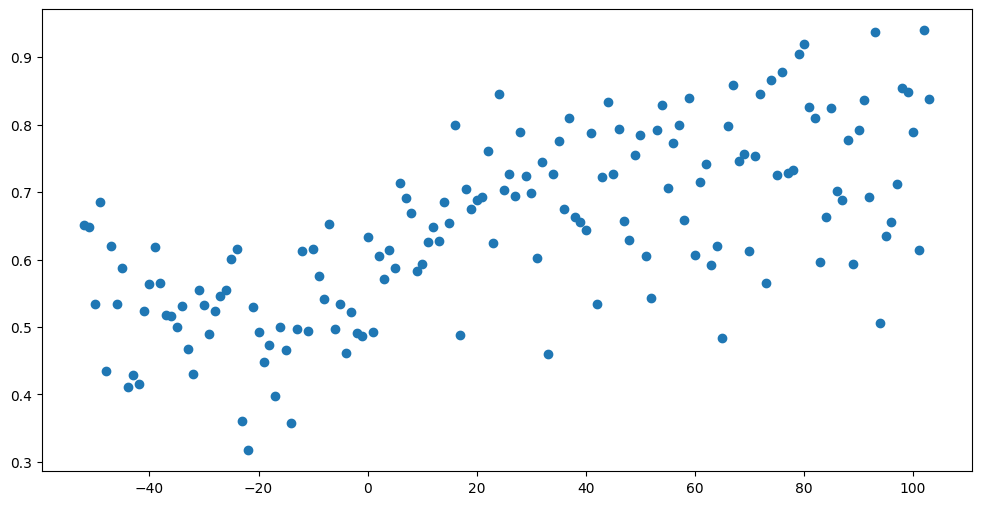

In [19]:
# 4. 막대 그래프로 시각화
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
types = '021C'

x = list(week_transitivity_dict.keys())
y = week_transitivity_dict.values()
ax.scatter(x, y)

    # # ax[idx].barplot(x=types, y=counts, palette="viridis") # Seaborn을 사용한 시각화
    # # plt.title("Triad Census Visualization")
    # # plt.xlabel("Triad Types")
    # # plt.ylabel("Count")
    # # plt.xticks(rotation=45) # x축 레이블 회전하여 가독성 향상
    # # plt.tight_layout()
    # # plt.show()

In [20]:
df_trans = pd.DataFrame(zip(week_transitivity_dict.keys(), week_transitivity_dict.values()), columns = ['rel_week', 'values'])
x = df_trans['rel_week'].values
y = df_trans['values'].values

cut = 0


In [21]:
df_trans['post0'] = (df_trans['rel_week'] >= cut).astype(int)
df_trans['slope_change'] = df_trans['rel_week'] * df_trans['post0']

X_pw = sm.add_constant(df_trans[['rel_week', 'post0', 'slope_change']])
model_pw = sm.OLS(y, X_pw).fit()
print(model_pw.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     56.46
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           1.40e-24
Time:                        20:29:20   Log-Likelihood:                 152.38
No. Observations:                 156   AIC:                            -296.8
Df Residuals:                     152   BIC:                            -284.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4912      0.026     18.911   

In [22]:
len(y)

156

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 정렬
df_trans = df_trans.sort_values('rel_week')

# 계수
b0 = model_pw.params['const']
b1 = model_pw.params['rel_week']
b2 = model_pw.params['post0']
b3 = model_pw.params['slope_change']

# x 범위
x_pre = df_trans[df_trans['rel_week'] < 0]['rel_week']
x_post = df_trans[df_trans['rel_week'] >= 0]['rel_week']

# 예측선
y_pre = b0 + b1 * x_pre
y_post = b0 + b1 * x_post + b2 + b3 * x_post


In [24]:
import statsmodels.api as sm
import numpy as np

# CI 계산용 x grid
x_grid = np.linspace(df_trans['rel_week'].min(),
                     df_trans['rel_week'].max(), 200)

pred_df = pd.DataFrame({
    'rel_week': x_grid
})
pred_df['post0'] = (pred_df['rel_week'] >= 0).astype(int)
pred_df['slope_change'] = pred_df['rel_week'] * pred_df['post0']

X_pred = sm.add_constant(pred_df[['rel_week', 'post0', 'slope_change']])

pred = model_pw.get_prediction(X_pred)
pred_ci = pred.summary_frame(alpha=0.05)


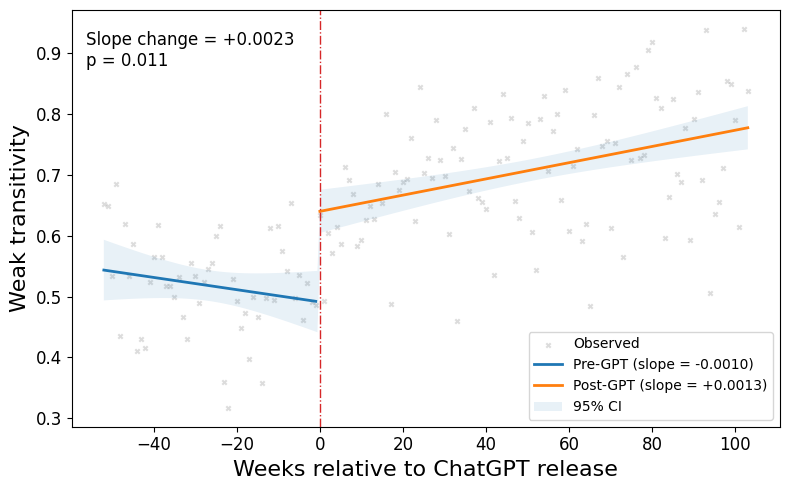

In [37]:
plt.figure(figsize=(8, 5))

# 원 데이터
plt.scatter(
    df_trans['rel_week'],
    df_trans['values'],
    alpha=0.4,
    label='Observed',
    color = 'darkgray', 
    s=10, 
    marker='x'
)

# 회귀선 (기존)
plt.plot(x_pre, y_pre, linewidth=2, label='Pre-GPT (slope = -0.0010)')
plt.plot(x_post, y_post, linewidth=2, label='Post-GPT (slope = +0.0013)')

# 🔹 95% 신뢰구간 추가
plt.fill_between(
    x_grid,
    pred_ci['mean_ci_lower'],
    pred_ci['mean_ci_upper'],
    alpha=0.1,
    label='95% CI'
)

# 기준선
plt.axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

# 라벨
plt.xlabel('Weeks relative to ChatGPT release', fontsize = 16)
plt.ylabel('Weak transitivity', fontsize = 16)
plt.legend()

# 주석
plt.text(
    0.02, 0.95,
    'Slope change = +0.0023\np = 0.011',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    fontsize = 12
)

plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig(f"Result_Fig4.png", dpi=300, bbox_inches='tight')
plt.show()
